# Лабораторная работа №3


## Импорт библиотек

In [165]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import probplot, shapiro
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    mean_absolute_error, mean_squared_error
)
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
DATA_PATH = Path("data")

## 1. Загрузка данных

In [166]:
def parse_city_year(path: Path):
    match = re.match(r"(.+?)_(\d{4})-", path.name)
    return match.group(1), int(match.group(2))

frames = []
for file in sorted(DATA_PATH.glob("*.parquet")):
    city, year = parse_city_year(file)
    df = pd.read_parquet(file)
    df = df.reset_index()
    if "time" in df.columns:
        df = df.rename(columns={"time": "datetime"})
    elif "index" in df.columns:
        df = df.rename(columns={"index": "datetime"})
    df["city"] = city
    df["source_year"] = year
    frames.append(df)

weather = pd.concat(frames, ignore_index=True)
weather["datetime"] = pd.to_datetime(weather["datetime"])
weather = weather.sort_values(["city", "datetime"]).reset_index(drop=True)

print(weather.shape)
print(weather["city"].value_counts())


(368208, 11)
city
Благовещенск       61368
Геленджик          61368
Москва             61368
Находка            61368
Санкт-Петербург    61368
Сочи               61368
Name: count, dtype: int64


## 2.1. Разведочный анализ данных

Проверяются: пропуски, частота данных, тренды, сезонность, распределения, выбросы, Q-Q plot, корреляции, межгородские различия и стационарность.

In [167]:
print("Диапазон дат:", weather["datetime"].min(), "—", weather["datetime"].max())
print("Количество городов:", weather["city"].nunique())


Диапазон дат: 2019-01-01 00:00:00 — 2025-12-31 23:00:00
Количество городов: 6


In [168]:
# Ресемплинг к дневной частоте.
daily = (
    weather.set_index("datetime")
    .groupby("city")
    .resample("1D")
    .agg({
        "temperature_2m": ["mean", "min", "max", "std"],
        "relative_humidity_2m": "mean",
        "precipitation": "sum",
        "rain": "sum",
        "snowfall": "sum",
        "weathercode": "max",
        "wind_speed_10m": ["mean", "max"],
        "surface_pressure": "mean",
    })
    .reset_index()
)
daily.columns = ["_".join(c).strip("_") for c in daily.columns]
daily = daily.rename(columns={
    "city_": "city",
    "datetime_": "datetime",
    "temperature_2m_mean": "temp_mean",
    "temperature_2m_min": "temp_min",
    "temperature_2m_max": "temp_max",
    "temperature_2m_std": "temp_std",
    "relative_humidity_2m_mean": "humidity_mean",
    "precipitation_sum": "precip_sum",
    "rain_sum": "rain_sum",
    "snowfall_sum": "snowfall_sum",
    "weathercode_max": "weathercode_max",
    "wind_speed_10m_mean": "wind_mean",
    "wind_speed_10m_max": "wind_max",
    "surface_pressure_mean": "pressure_mean",
})


num_cols = daily.select_dtypes(include=np.number).columns
for city in daily["city"].unique():
    mask = daily["city"] == city
    daily.loc[mask, num_cols] = daily.loc[mask, num_cols].interpolate(limit_direction="both")

for col in ["precip_sum", "rain_sum", "snowfall_sum"]:
    daily[col] = daily[col].fillna(0)

daily["year"] = daily["datetime"].dt.year
daily["month"] = daily["datetime"].dt.month
daily["day"] = daily["datetime"].dt.day
daily["dayofweek"] = daily["datetime"].dt.dayofweek
daily["dayofyear"] = daily["datetime"].dt.dayofyear

def season(month):
    if month in [12, 1, 2]: return "winter"
    if month in [3, 4, 5]: return "spring"
    if month in [6, 7, 8]: return "summer"
    return "autumn"
daily["season"] = daily["month"].apply(season)

display(daily.head())
print(daily.shape)

,city,datetime,temp_mean,temp_min,temp_max,temp_std,humidity_mean,precip_sum,rain_sum,snowfall_sum,weathercode_max,wind_mean,wind_max,pressure_mean,year,month,day,dayofweek,dayofyear,season
0,Благовещенск,2019-01-01,-14.037499,-20.900000,-10.7,2.794375,63.083333,0.0,0.0,0.0,3,13.400001,18.1,1008.362488,2019,1,1,1,1,winter
1,Благовещенск,2019-01-02,-18.391666,-23.200001,-11.4,3.825875,72.875000,0.0,0.0,0.0,0,10.904167,14.3,1010.916687,2019,1,2,2,2,winter
2,Благовещенск,2019-01-03,-18.770834,-23.200001,-13.8,2.882855,70.041667,0.0,0.0,0.0,0,8.770833,15.2,1010.370850,2019,1,3,3,3,winter
3,Благовещенск,2019-01-04,-20.787500,-24.100000,-16.9,2.195710,75.166667,0.0,0.0,0.0,3,8.083333,12.1,1004.587463,2019,1,4,4,4,winter
4,Благовещенск,2019-01-05,-19.866667,-24.500000,-12.0,4.056628,72.333333,0.0,0.0,0.0,2,10.708333,15.1,1007.562500,2019,1,5,5,5,winter


(15342, 20)


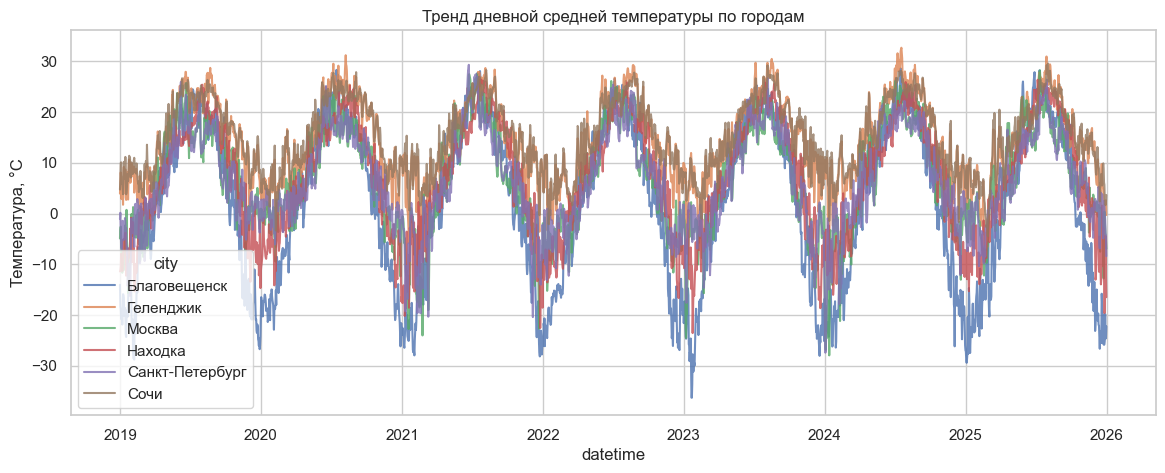

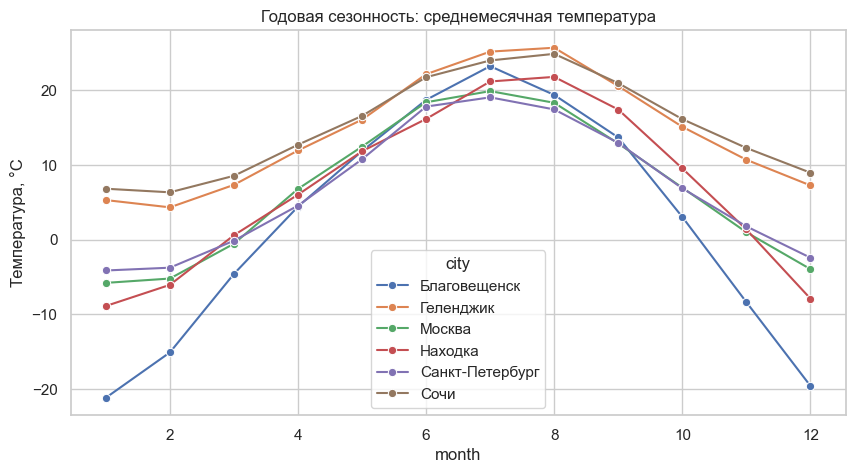

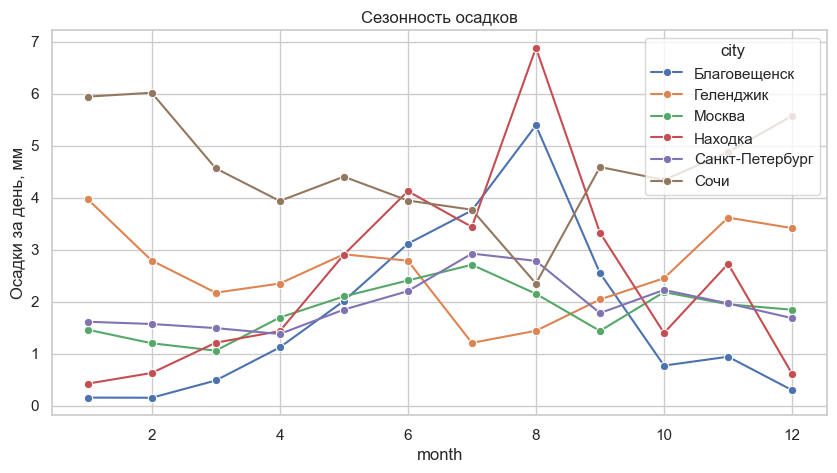

In [169]:
plt.figure(figsize=(14, 5))
sns.lineplot(data=daily, x="datetime", y="temp_mean", hue="city", alpha=0.8)
plt.title("Тренд дневной средней температуры по городам")
plt.ylabel("Температура, °C")
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily, x="month", y="temp_mean", hue="city", estimator="mean", errorbar=None, marker="o")
plt.title("Годовая сезонность: среднемесячная температура")
plt.ylabel("Температура, °C")
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily, x="month", y="precip_sum", hue="city", estimator="mean", errorbar=None, marker="o")
plt.title("Сезонность осадков")
plt.ylabel("Осадки за день, мм")
plt.show()

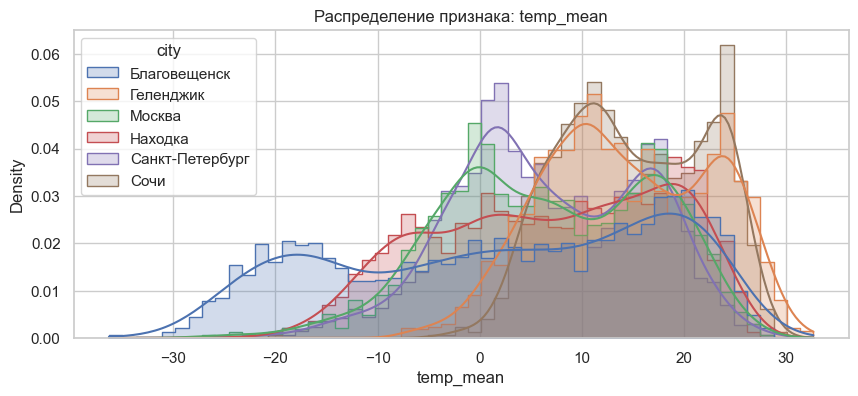

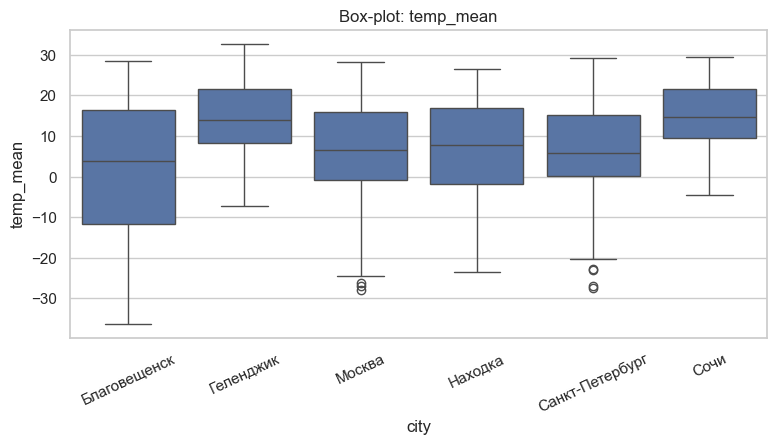

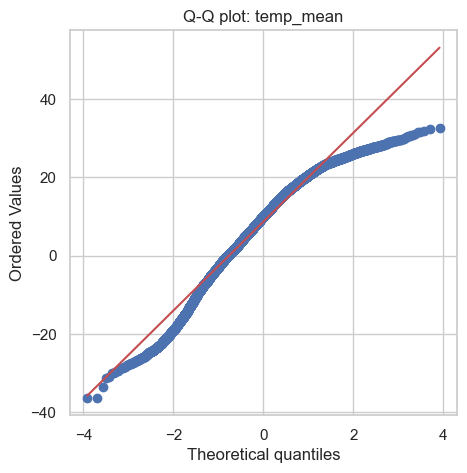

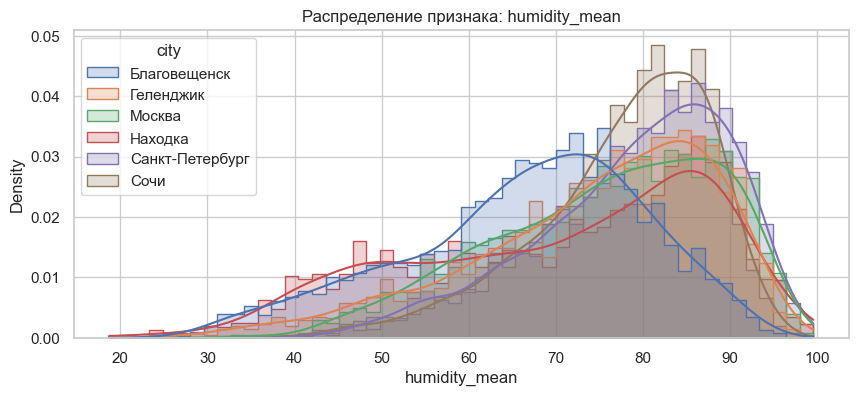

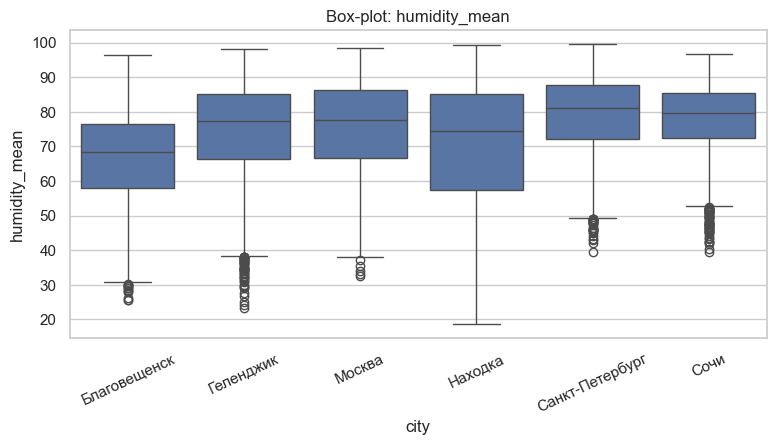

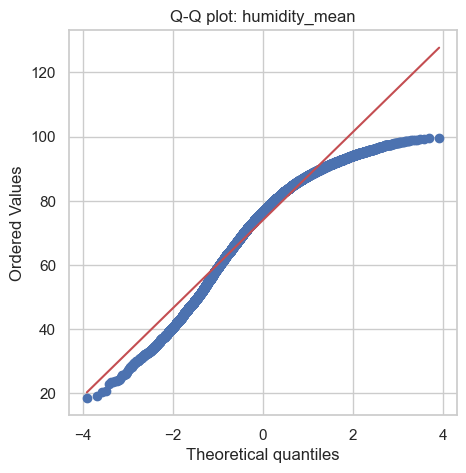

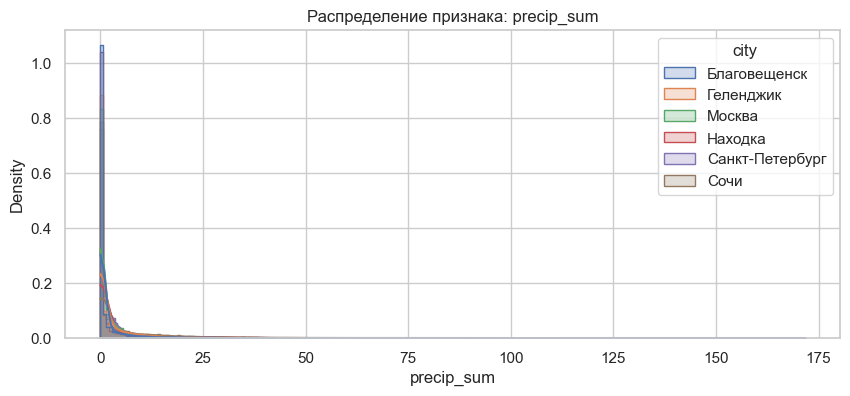

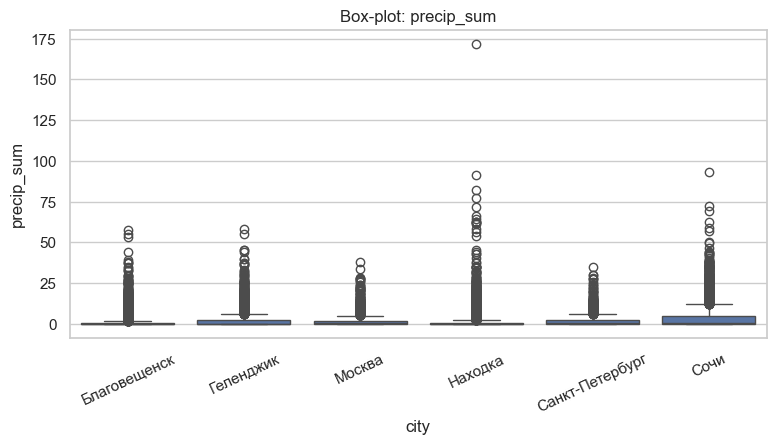

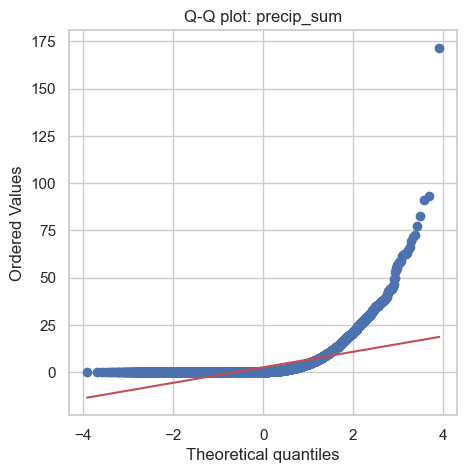

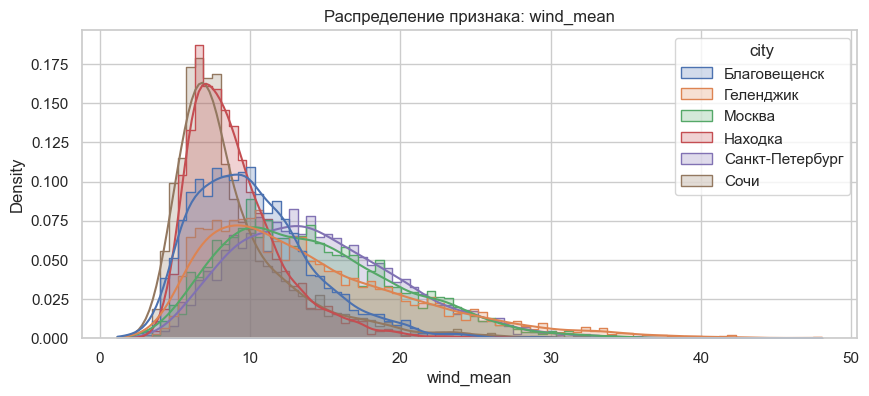

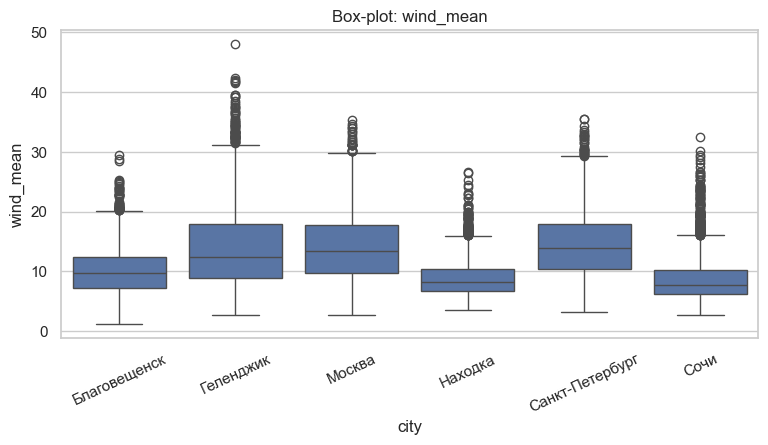

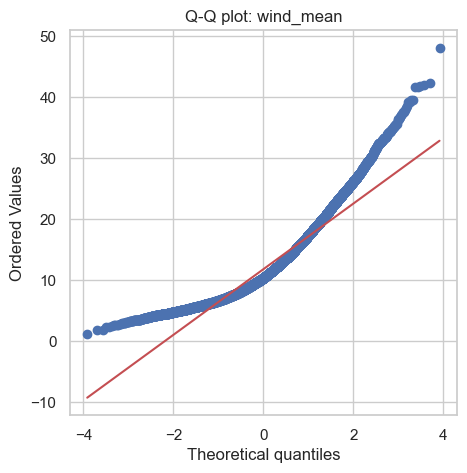

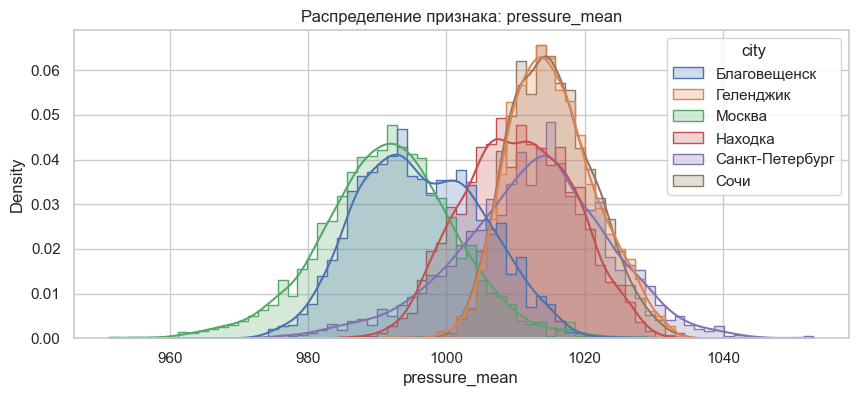

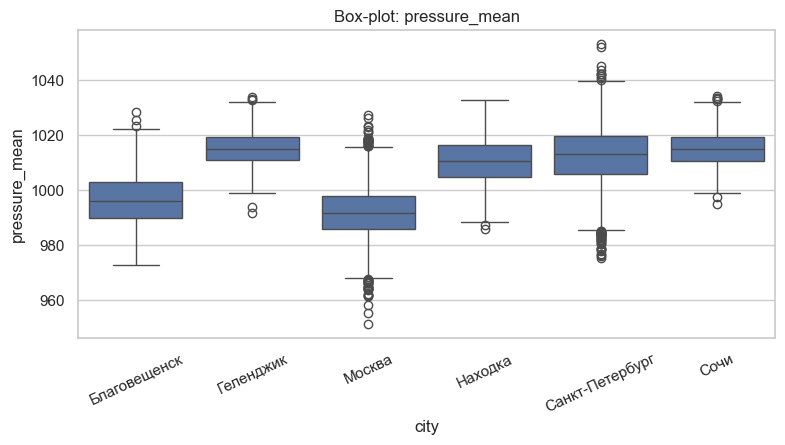

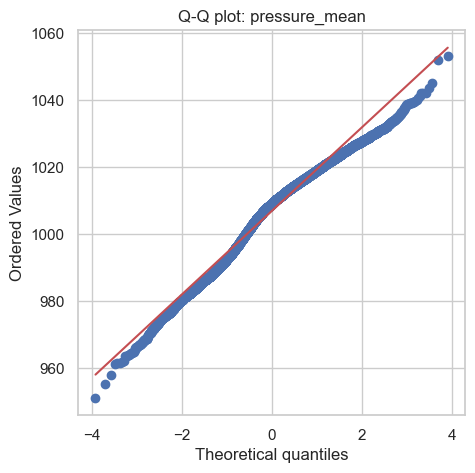

In [170]:
eda_cols = ["temp_mean", "humidity_mean", "precip_sum", "wind_mean", "pressure_mean"]
for col in eda_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=daily, x=col, hue="city", kde=True, element="step", stat="density", common_norm=False)
    plt.title(f"Распределение признака: {col}")
    plt.show()

    plt.figure(figsize=(9, 4))
    sns.boxplot(data=daily, x="city", y=col)
    plt.xticks(rotation=25)
    plt.title(f"Box-plot: {col}")
    plt.show()

    plt.figure(figsize=(5, 5))
    probplot(daily[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q-Q plot: {col}")
    plt.show()

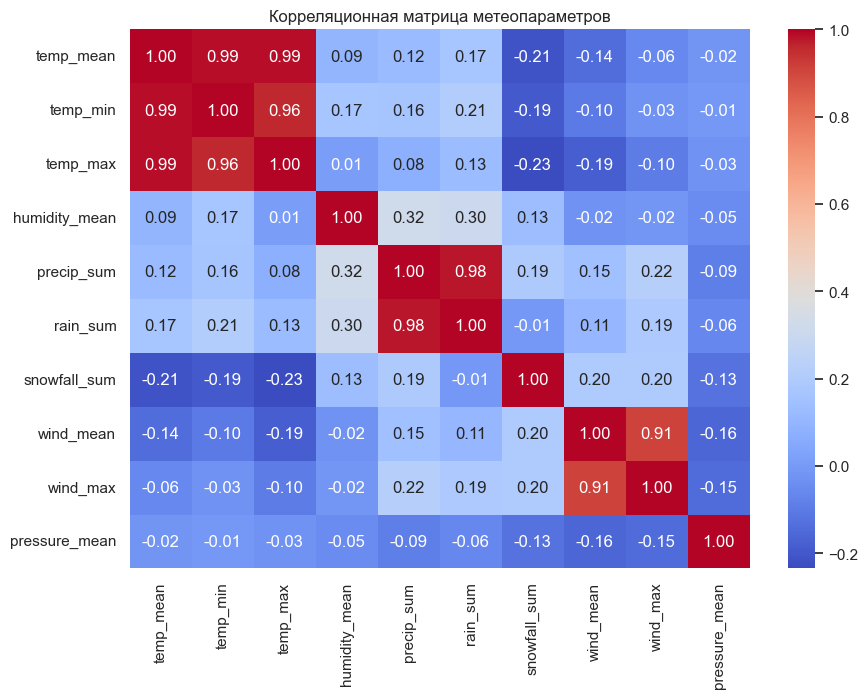

,mean_temp,temp_amplitude,annual_precip_mean,mean_wind,mean_pressure
city,,,,,
Сочи,15.044275,36.200001,1649.671509,8.844128,1015.125610
Геленджик,14.360490,44.000000,947.714294,14.022651,1015.330383
Находка,6.991479,54.000000,889.285706,8.956903,1010.371643
Москва,6.831827,59.400002,677.857117,14.136086,991.618774
Санкт-Петербург,6.790927,61.200001,716.342896,14.594144,1012.383728
Благовещенск,2.210316,65.599998,635.328552,10.189500,996.415527


In [171]:
plt.figure(figsize=(10, 7))
corr_cols = ["temp_mean", "temp_min", "temp_max", "humidity_mean", "precip_sum", "rain_sum", "snowfall_sum", "wind_mean", "wind_max", "pressure_mean"]
sns.heatmap(daily[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица метеопараметров")
plt.show()

climate_profiles = daily.groupby("city").agg(
    mean_temp=("temp_mean", "mean"),
    temp_amplitude=("temp_max", lambda x: x.max() - x.min()),
    annual_precip_mean=("precip_sum", lambda x: x.sum() / daily["year"].nunique()),
    mean_wind=("wind_mean", "mean"),
    mean_pressure=("pressure_mean", "mean")
).sort_values("mean_temp", ascending=False)

display(climate_profiles)

In [172]:
# Межгородские выбросы по температуре и осадкам через IQR.
outlier_rows = []
for city, group in daily.groupby("city"):
    for col in ["temp_mean", "precip_sum", "wind_max"]:
        q1, q3 = group[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        share = ((group[col] < low) | (group[col] > high)).mean()
        outlier_rows.append({"city": city, "feature": col, "outlier_share": share})

display(pd.DataFrame(outlier_rows).pivot(index="city", columns="feature", values="outlier_share"))

feature,precip_sum,temp_mean,wind_max
city,,,
Благовещенск,0.184591,0.000000,0.019163
Геленджик,0.136097,0.000000,0.013688
Москва,0.104419,0.001173,0.010168
Находка,0.176770,0.000000,0.026594
Санкт-Петербург,0.086038,0.001564,0.010950
Сочи,0.131404,0.000000,0.047321


# ADF-тест стационарности и дифференцирование.

In [173]:
adf_rows = []
for city, group in daily.groupby("city"):
    series = group["temp_mean"].dropna()
    p_raw = adfuller(series, autolag="AIC")[1]
    p_diff = adfuller(series.diff().dropna(), autolag="AIC")[1]
    adf_rows.append({"city": city, "ADF_p_raw": p_raw, "ADF_p_diff": p_diff})

adf_table = pd.DataFrame(adf_rows)
display(adf_table)

,city,ADF_p_raw,ADF_p_diff
0,Благовещенск,0.013476,1.731510e-11
1,Геленджик,0.033897,2.597210e-30
2,Москва,0.022534,3.638932e-30
3,Находка,0.051902,1.600697e-16
4,Санкт-Петербург,0.020960,2.029875e-30
5,Сочи,0.026736,8.607586e-27


### Выводы по EDA

1. Данные имеют выраженную годовую сезонность и различимые климатические профили.
2. Для месячного горизонта прогнозирования дневной ресемплинг оправдан: он уменьшает почасовой шум и сохраняет физически важную динамику.
3. Пропуски корректно обрабатывать временной интерполяцией, так как температура, давление и влажность меняются инерционно.
4. Осадки имеют ненормальное распределение с большим числом нулей; поэтому для них важны агрегаты за окно.
5. Выбросы не удаляются автоматически, так как они могут соответствовать опасным погодным явлениям.
6. Нестационарность учитывается календарными признаками, лагами, скользящими статистиками и дифференцированием для диагностического анализа.

## 2.2. Инжиниринг признаков для временных рядов

Создаются календарные, циклические, лаговые, скользящие, динамические и агрегированные признаки. Также добавляется климатическая норма для дня года.

In [174]:
# Климатическая норма для дня года: среднее за все годы по городу и дню года.
daily["climate_norm_temp"] = daily.groupby(["city", "dayofyear"])["temp_mean"].transform("mean")

# Циклические признаки месяца и дня года.
daily["month_sin"] = np.sin(2 * np.pi * daily["month"] / 12)
daily["month_cos"] = np.cos(2 * np.pi * daily["month"] / 12)
daily["doy_sin"] = np.sin(2 * np.pi * daily["dayofyear"] / 365)
daily["doy_cos"] = np.cos(2 * np.pi * daily["dayofyear"] / 365)

# Динамика температуры и давления.
daily["temp_velocity"] = daily.groupby("city")["temp_mean"].diff()
daily["temp_acceleration"] = daily.groupby("city")["temp_velocity"].diff()
daily["pressure_growth"] = daily.groupby("city")["pressure_mean"].diff()

# Лаги и скользящие статистики.
for lag in [1, 2, 3, 7, 14, 30, 60, 365]:
    daily[f"temp_lag_{lag}"] = daily.groupby("city")["temp_mean"].shift(lag)
    daily[f"pressure_lag_{lag}"] = daily.groupby("city")["pressure_mean"].shift(lag)

for window in [3, 7, 14, 30]:
    daily[f"temp_roll_mean_{window}"] = daily.groupby("city")["temp_mean"].transform(lambda s: s.shift(1).rolling(window).mean())
    daily[f"temp_roll_std_{window}"] = daily.groupby("city")["temp_mean"].transform(lambda s: s.shift(1).rolling(window).std())
    daily[f"precip_roll_sum_{window}"] = daily.groupby("city")["precip_sum"].transform(lambda s: s.shift(1).rolling(window).sum())
    daily[f"wind_roll_max_{window}"] = daily.groupby("city")["wind_max"].transform(lambda s: s.shift(1).rolling(window).max())

print("Количество признаков после feature engineering:", daily.shape[1])

Количество признаков после feature engineering: 60


In [175]:
# Окна для классификации климатического типа.
climate_map = {
    "Москва": "Умеренно-континентальный",
    "Санкт-Петербург": "Умеренно-континентальный",
    "Сочи": "Черноморский морской",
    "Геленджик": "Черноморский морской",
    "Благовещенск": "Дальневосточный",
    "Находка": "Дальневосточный",
}

WINDOW = 30   # фиксированный период для классификации: 30 дней
STEP = 14
base_cols = ["temp_mean", "temp_min", "temp_max", "humidity_mean", "precip_sum", "snowfall_sum", "wind_mean", "wind_max", "pressure_mean"]

rows = []
for city, group in daily.groupby("city"):
    group = group.sort_values("datetime").reset_index(drop=True)
    for start in range(0, len(group) - WINDOW + 1, STEP):
        w = group.iloc[start:start + WINDOW]
        row = {
            "city": city,
            "climate_type": climate_map[city],
            "year": int(w["year"].iloc[-1]),
            "month": int(w["month"].iloc[-1]),
            "season": w["season"].iloc[-1],
            "start_date": w["datetime"].iloc[0],
            "end_date": w["datetime"].iloc[-1],
            "temp_amplitude": w["temp_max"].max() - w["temp_min"].min(),
            "precip_days": (w["precip_sum"] > 0).sum(),
            "max_wind": w["wind_max"].max(),
            "mean_temp": w["temp_mean"].mean(),
            "std_temp": w["temp_mean"].std(),
            "mean_pressure": w["pressure_mean"].mean(),
            "std_pressure": w["pressure_mean"].std(),
            "mean_humidity": w["humidity_mean"].mean(),
        }
        for col in base_cols:
            row[f"{col}_mean"] = w[col].mean()
            row[f"{col}_std"] = w[col].std()
            row[f"{col}_min"] = w[col].min()
            row[f"{col}_max"] = w[col].max()
        rows.append(row)

win = pd.DataFrame(rows).dropna().reset_index(drop=True)
display(win.head())
print(win["climate_type"].value_counts())

,city,climate_type,year,month,season,start_date,end_date,temp_amplitude,precip_days,max_wind,...,wind_mean_min,wind_mean_max,wind_max_mean,wind_max_std,wind_max_min,wind_max_max,pressure_mean_mean,pressure_mean_std,pressure_mean_min,pressure_mean_max
0,Благовещенск,Дальневосточный,2019,1,winter,2019-01-01,2019-01-30,22.000000,6,22.400000,...,5.787500,16.949999,15.300000,2.894585,10.0,22.400000,1003.387390,5.399860,993.004150,1011.049988
1,Благовещенск,Дальневосточный,2019,2,winter,2019-01-15,2019-02-13,30.100000,6,22.400000,...,5.591667,16.949999,15.609998,2.694099,10.0,22.400000,1002.905518,5.194025,993.004150,1011.262512
2,Благовещенск,Дальневосточный,2019,2,winter,2019-01-29,2019-02-27,41.400002,4,24.200001,...,5.591667,18.824999,16.040001,2.878529,11.1,24.200001,1002.068054,5.157636,993.075012,1011.262512
3,Благовещенск,Дальневосточный,2019,3,spring,2019-02-12,2019-03-13,34.099998,7,27.100000,...,5.070833,19.200001,16.110001,4.748600,9.0,27.100000,999.273315,5.894956,986.033386,1011.262512
4,Благовещенск,Дальневосточный,2019,3,spring,2019-02-26,2019-03-27,23.400002,9,27.100000,...,5.070833,19.200001,17.160000,5.061934,9.0,27.100000,996.092773,5.530080,985.104187,1005.112488


climate_type
Дальневосточный             362
Черноморский морской        362
Умеренно-континентальный    362
Name: count, dtype: int64


# PCA для визуализации разделимости климатов.

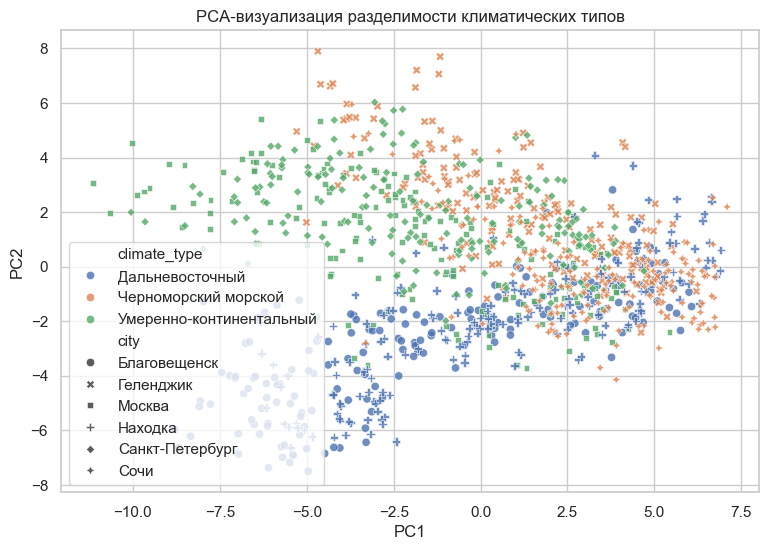

Explained variance ratio: [0.35746606 0.17803259]


In [176]:
pca_features = win.select_dtypes(include=np.number).drop(columns=["year", "month"])
scaled = StandardScaler().fit_transform(pca_features)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_xy = pca.fit_transform(scaled)
pca_df = pd.DataFrame({"PC1": pca_xy[:, 0], "PC2": pca_xy[:, 1], "climate_type": win["climate_type"], "city": win["city"]})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="climate_type", style="city", alpha=0.8)
plt.title("PCA-визуализация разделимости климатических типов")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

### Обоснование размеров окон и лагов

- Окно 30 дней соответствует целевому горизонту прогноза и отражает устойчивый погодный режим.
- Лаг 30 дней учитывает месячную сезонность.
- Лаг 365 дней учитывает годовую климатическую повторяемость.
- Скользящие окна 7, 14 и 30 дней соответствуют недельным, двухнедельным и месячным синоптическим процессам.

## 2.3. Построение модели классификации

В notebook используется воспроизводимый baseline: Random Forest на агрегированных 30-дневных окнах.

В рамках лабораторной работы baseline выбран потому, что он быстрее обучается, устойчив на небольшом объеме данных и дает интерпретируемые важности признаков.

Дополнительно обучается router-классификатор города. Он нужен для интегрированного pipeline: если на вход поступает неизвестный ряд, система сначала определяет климатический тип, затем наиболее вероятный город-представитель и только после этого выбирает специализированную модель прогноза.

Модели, которые хуже подходят: линейная регрессия без лагов, kNN на сырых рядах, простая ARIMA для мультивариантной классификации.

In [177]:
meta_cols = ["city", "climate_type", "season", "start_date", "end_date"]
X = win.drop(columns=meta_cols)
y = win["climate_type"]
y_city = win["city"]

# Разделение по времени: 2019–2023 train, 2024 validation, 2025 test.
train_mask = win["year"] <= 2023
val_mask = win["year"] == 2024
test_mask = win["year"] == 2025

# Классификатор климатического типа.
classifier = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1
    ))
])

classifier.fit(X.loc[train_mask], y.loc[train_mask])
y_val_pred = classifier.predict(X.loc[val_mask])
y_pred = classifier.predict(X.loc[test_mask])
y_proba = classifier.predict_proba(X.loc[test_mask])
classes = classifier.named_steps["rf"].classes_

# Router-классификатор города для выбора city-specific forecasting-модели.
city_classifier = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1
    ))
])

city_classifier.fit(X.loc[train_mask], y_city.loc[train_mask])
y_city_val_pred = city_classifier.predict(X.loc[val_mask])
y_city_pred = city_classifier.predict(X.loc[test_mask])

print("Длина тестируемого временного ряда:", WINDOW, "дней")
print("Validation accuracy по климату:", accuracy_score(y.loc[val_mask], y_val_pred))
print("Test classification report по климату:")
print(classification_report(y.loc[test_mask], y_pred))
print("Validation accuracy router по городу:", accuracy_score(y_city.loc[val_mask], y_city_val_pred))
print("Test accuracy router по городу:", accuracy_score(y_city.loc[test_mask], y_city_pred))

Длина тестируемого временного ряда: 30 дней
Validation accuracy по климату: 0.9166666666666666
Test classification report по климату:
                          precision    recall  f1-score   support

         Дальневосточный       0.62      0.98      0.76        52
Умеренно-континентальный       1.00      0.42      0.59        52
    Черноморский морской       0.94      0.94      0.94        52

                accuracy                           0.78       156
               macro avg       0.85      0.78      0.77       156
            weighted avg       0.85      0.78      0.77       156

Validation accuracy router по городу: 0.8974358974358975
Test accuracy router по городу: 0.7115384615384616


## 2.4. Оценка качества классификации

Рассчитываются Accuracy, Precision, Recall, F1-score macro/weighted, confusion matrix, ROC-AUC One-vs-Rest.

,value
accuracy,0.782051
precision_macro,0.854753
recall_macro,0.782051
f1_macro,0.766032
f1_weighted,0.766032
roc_auc_ovr,0.952940


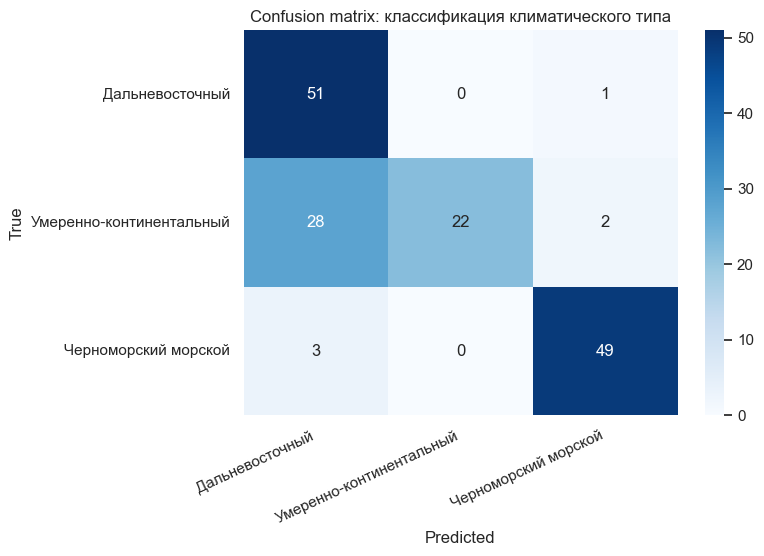

In [178]:
classification_metrics = {
    "accuracy": accuracy_score(y.loc[test_mask], y_pred),
    "precision_macro": precision_score(y.loc[test_mask], y_pred, average="macro"),
    "recall_macro": recall_score(y.loc[test_mask], y_pred, average="macro"),
    "f1_macro": f1_score(y.loc[test_mask], y_pred, average="macro"),
    "f1_weighted": f1_score(y.loc[test_mask], y_pred, average="weighted"),
}

y_test_bin = label_binarize(y.loc[test_mask], classes=classes)
classification_metrics["roc_auc_ovr"] = roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="macro")

display(pd.Series(classification_metrics).to_frame("value"))

cm = confusion_matrix(y.loc[test_mask], y_pred, labels=classes)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.title("Confusion matrix: классификация климатического типа")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.show()

,climate_error_rate
season,
autumn,0.238095
spring,0.214286
summer,0.305556
winter,0.111111


,climate_error_rate,city_router_error_rate
city,,
Благовещенск,0.000000,0.000000
Геленджик,0.000000,0.423077
Москва,0.923077,0.923077
Находка,0.038462,0.038462
Санкт-Петербург,0.230769,0.230769
Сочи,0.115385,0.115385


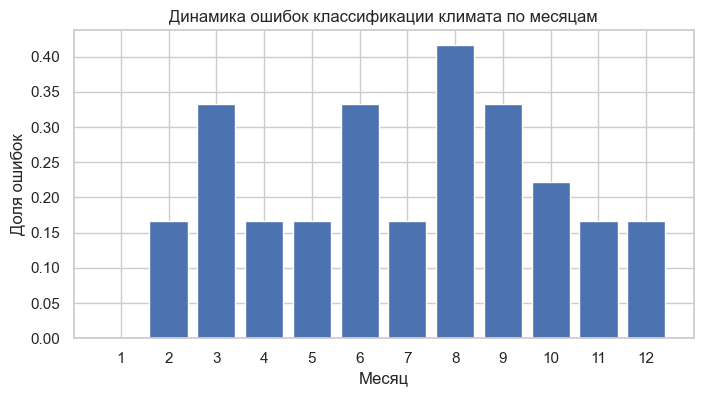

In [179]:
err = win.loc[test_mask, ["city", "climate_type", "season", "month", "year"]].copy()
err["pred"] = y_pred
err["pred_city"] = y_city_pred
err["is_error"] = (err["climate_type"] != err["pred"]).astype(float)
err["is_city_error"] = (err["city"] != err["pred_city"]).astype(float)

display(err.groupby(["season"])["is_error"].mean().to_frame("climate_error_rate"))
display(err.groupby(["city"])[["is_error", "is_city_error"]].mean().rename(columns={"is_error": "climate_error_rate", "is_city_error": "city_router_error_rate"}))

month_error = err.groupby("month")["is_error"].mean()
plt.figure(figsize=(8, 4))
plt.bar(month_error.index.astype(str), month_error.values)
plt.title("Динамика ошибок классификации климата по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Доля ошибок")
plt.show()

# Важность признаков: встроенная важность RF + permutation importance.

,rf_importance
pressure_mean_min,0.143971
wind_mean_mean,0.077247
pressure_mean_mean,0.067392
wind_mean_std,0.049633
mean_pressure,0.048377
pressure_mean_std,0.047016
std_pressure,0.046254
wind_mean_max,0.041844
wind_max_mean,0.040111
temp_min_mean,0.030506


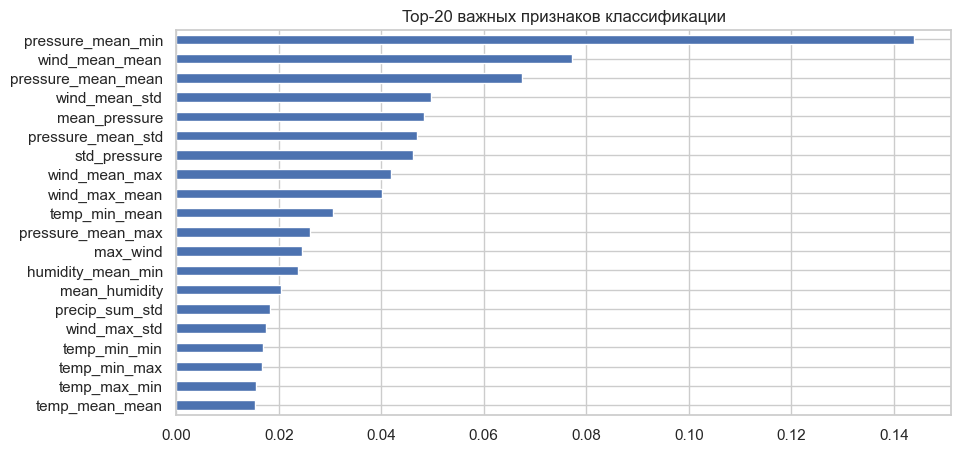

,permutation_importance
pressure_mean_min,0.153846
wind_mean_mean,0.038462
pressure_mean_mean,0.025641
wind_mean_std,0.019231
std_pressure,0.019231
mean_pressure,0.019231
humidity_mean_max,0.012821
humidity_mean_min,0.012821
temp_min_min,0.012821
temp_min_mean,0.012821


In [180]:
rf = classifier.named_steps["rf"]
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
display(feature_importance.head(20).to_frame("rf_importance"))

plt.figure(figsize=(10, 5))
feature_importance.head(20).sort_values().plot(kind="barh")
plt.title("Top-20 важных признаков классификации")
plt.show()

perm = permutation_importance(classifier, X.loc[test_mask], y.loc[test_mask], n_repeats=1, random_state=RANDOM_STATE, n_jobs=1)
perm_importance = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
display(perm_importance.head(15).to_frame("permutation_importance"))

### Вывод по классификации

Классы в основной задаче — это климатические типы, а не отдельные города. Это соответствует условию, где для каждого климатического типа представлены минимум два города. Дополнительный city-router используется только на этапе интеграции, чтобы выбрать конкретную городскую forecasting-модель.

Наиболее сложными являются пары городов внутри одного климатического типа, например Сочи/Геленджик и Москва/Санкт-Петербург. Лучшие признаки — температурная амплитуда, давление, влажность, осадки и ветровые характеристики. 

## 2.5. Построение моделей прогнозирования

Для каждого города обучается отдельная модель прогнозирования температуры на 30 дней вперед. Разделение по годам:

- 2019–2023: train
- 2024: validation
- 2025: test

Формулировка: признаки — последние N дней и календарные признаки, цель — 30 будущих дневных температур.

In [181]:
FORECAST_HORIZON = 30
forecast_rows = []
city_models = {}
city_best_alpha = {}
forecast_predictions = []

common_feature_cols = [
    "month", "dayofyear", "month_sin", "month_cos", "doy_sin", "doy_cos",
    "temp_mean", "temp_min", "temp_max", "humidity_mean", "precip_sum", "wind_mean", "wind_max", "pressure_mean",
    "climate_norm_temp", "temp_velocity", "temp_acceleration", "pressure_growth"
]
lag_feature_cols = []
for lag in [1, 2, 3, 7, 14, 30, 60, 365]:
    lag_feature_cols += [f"temp_lag_{lag}", f"pressure_lag_{lag}"]
for window in [3, 7, 14, 30]:
    lag_feature_cols += [f"temp_roll_mean_{window}", f"temp_roll_std_{window}", f"precip_roll_sum_{window}", f"wind_roll_max_{window}"]
forecast_features = common_feature_cols + lag_feature_cols

alpha_grid = [0.1, 1.0, 10.0, 100.0]

for city, group in daily.groupby("city"):
    g = group.sort_values("datetime").copy()
    for h in range(1, FORECAST_HORIZON + 1):
        g[f"target_h{h}"] = g["temp_mean"].shift(-h)
    target_cols = [f"target_h{h}" for h in range(1, FORECAST_HORIZON + 1)]
    data = g.dropna(subset=forecast_features + target_cols).copy()

    train = data[data["year"] <= 2023]
    val = data[data["year"] == 2024]
    test = data[data["year"] == 2025]

    
    best_alpha = None
    best_val_mae = np.inf
    for alpha in alpha_grid:
        candidate = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=alpha))
        ])
        candidate.fit(train[forecast_features], train[target_cols])
        val_pred = candidate.predict(val[forecast_features])
        val_mae = mean_absolute_error(val[target_cols].values, val_pred)
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_alpha = alpha

    
    train_val = pd.concat([train, val], ignore_index=True)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=best_alpha))
    ])
    model.fit(train_val[forecast_features], train_val[target_cols])
    city_models[city] = model
    city_best_alpha[city] = {"best_alpha": best_alpha, "val_MAE": best_val_mae}

    pred = model.predict(test[forecast_features])
    true = test[target_cols].values

    for h in range(FORECAST_HORIZON):
        y_true_h = true[:, h]
        y_pred_h = pred[:, h]
        mae = mean_absolute_error(y_true_h, y_pred_h)
        rmse = np.sqrt(mean_squared_error(y_true_h, y_pred_h))

        # MAPE для температуры методологически нестабилен около 0°C и при отрицательных значениях.
        # Поэтому он считается только на точках, где |T| >= 1°C, а WAPE используется как основная относительная метрика.
        safe_mask = np.abs(y_true_h) >= 1.0
        mape = np.mean(np.abs((y_true_h[safe_mask] - y_pred_h[safe_mask]) / y_true_h[safe_mask])) * 100 if safe_mask.any() else np.nan
        wape = np.sum(np.abs(y_true_h - y_pred_h)) / np.sum(np.abs(y_true_h)) * 100
        direction_acc = np.mean(np.sign(np.diff(y_true_h)) == np.sign(np.diff(y_pred_h))) if len(y_true_h) > 1 else np.nan
        forecast_rows.append({"city": city, "horizon": h + 1, "MAE": mae, "RMSE": rmse, "MAPE_safe": mape, "WAPE": wape, "direction_accuracy": direction_acc})

    
    tmp = test[["datetime", "city", "temp_mean"]].copy()
    tmp["y_true_h30"] = true[:, 29]
    tmp["y_pred_h30"] = pred[:, 29]
    forecast_predictions.append(tmp)

forecast_metrics = pd.DataFrame(forecast_rows)
forecast_pred_df = pd.concat(forecast_predictions, ignore_index=True)
alpha_table = pd.DataFrame.from_dict(city_best_alpha, orient="index").reset_index().rename(columns={"index": "city"})

display(alpha_table)
display(forecast_metrics.groupby("city")[["MAE", "RMSE", "MAPE_safe", "WAPE", "direction_accuracy"]].mean().sort_values("MAE"))

,city,best_alpha,val_MAE
0,Благовещенск,100.0,2.668907
1,Геленджик,100.0,2.834884
2,Москва,10.0,3.358029
3,Находка,10.0,2.249124
4,Санкт-Петербург,100.0,3.197190
5,Сочи,100.0,2.170752


,MAE,RMSE,MAPE_safe,WAPE,direction_accuracy
city,,,,,
Находка,2.253137,2.893735,45.170253,19.228160,0.511876
Сочи,2.527205,3.331276,31.854086,16.577911,0.499401
Благовещенск,2.817337,3.613177,35.423712,20.259044,0.517665
Геленджик,2.983178,3.799663,37.781512,19.941189,0.508383
Санкт-Петербург,3.050392,3.749575,58.631050,32.616378,0.505689
Москва,3.352657,4.087523,56.744054,32.534019,0.505988


### Обоснование forecasting-архитектуры

Выбрана отдельная Ridge-модель для каждого города. Это регуляризованная линейная multi-output модель, которая предсказывает сразу 30 будущих дневных температур. Она используется как устойчивый baseline: быстро обучается, хорошо работает с большим количеством лаговых и календарных признаков и снижает риск переобучения на ограниченной истории 2019–2025.

Validation-год 2024 используется для подбора гиперпараметра `alpha`. После выбора `alpha` финальная модель обучается на 2019–2024, а 2025 остается независимым test-периодом.

Для production-версии возможна замена на разные нейросетевые модели:

- LSTM/GRU для континентальных городов с сильной инерцией и резкими изменениями.
- TCN для устойчивых локальных паттернов.
- Transformer Encoder для дальних сезонных зависимостей.

Одна универсальная модель хуже, потому что города имеют разные амплитуды, сезонность, влажность, ветровой режим и распределение осадков.

## 2.6. Оценка качества прогнозирования

Рассчитываются MAE, RMSE, WAPE, direction accuracy и диагностические тесты остатков. MAPE также выводится как `MAPE_safe`, но интерпретируется осторожно: для температуры эта метрика нестабильна около 0°C и при отрицательных значениях, поэтому основной относительной метрикой является WAPE.

,city,horizon,MAE,RMSE,MAPE_safe,WAPE,direction_accuracy
0,Благовещенск,1,1.866728,2.452192,23.677277,13.323165,0.565868
1,Благовещенск,2,2.476770,3.259454,31.462137,17.703593,0.497006
2,Благовещенск,3,2.592297,3.416599,33.207360,18.568603,0.479042
3,Благовещенск,4,2.618862,3.449693,32.661259,18.805400,0.517964
4,Благовещенск,5,2.750756,3.529519,34.120086,19.806112,0.500000


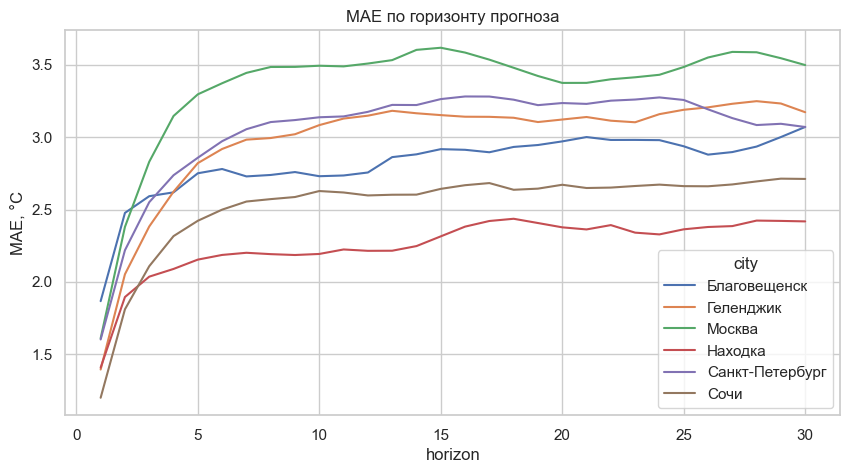

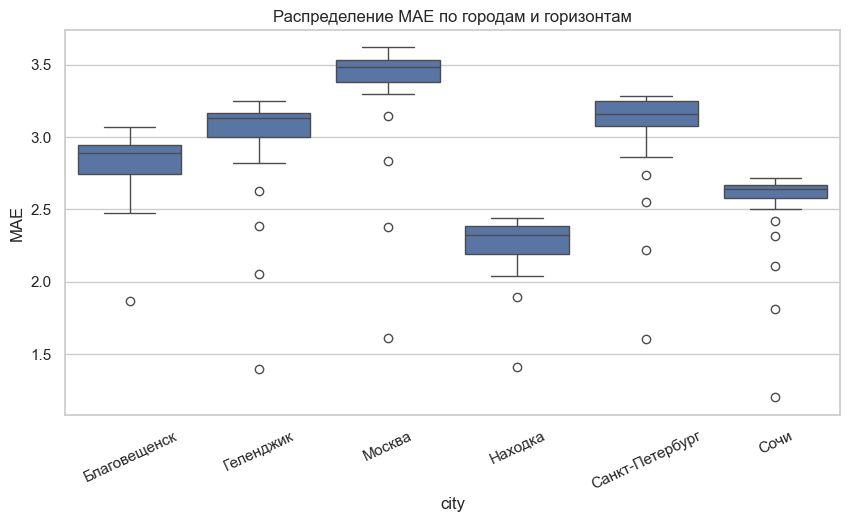

In [182]:
display(forecast_metrics.head())

plt.figure(figsize=(10, 5))
sns.lineplot(data=forecast_metrics, x="horizon", y="MAE", hue="city")
plt.title("MAE по горизонту прогноза")
plt.ylabel("MAE, °C")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=forecast_metrics, x="city", y="MAE")
plt.xticks(rotation=25)
plt.title("Распределение MAE по городам и горизонтам")
plt.show()

# Прогнозы и реальные значения для горизонта 30 дней.

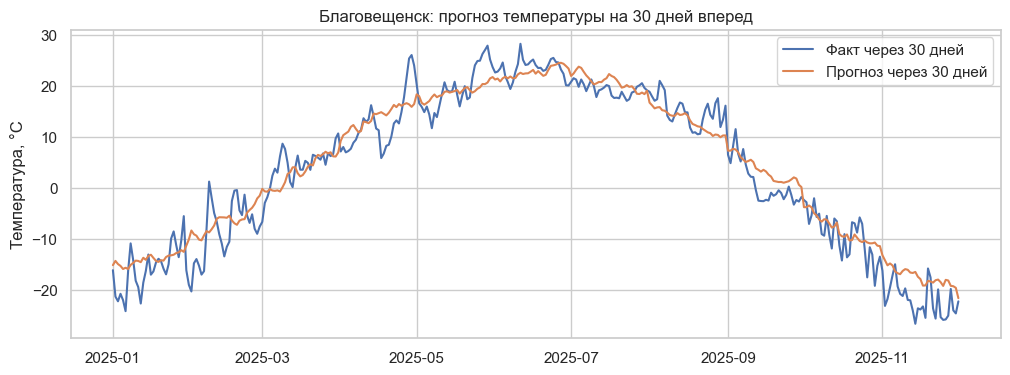

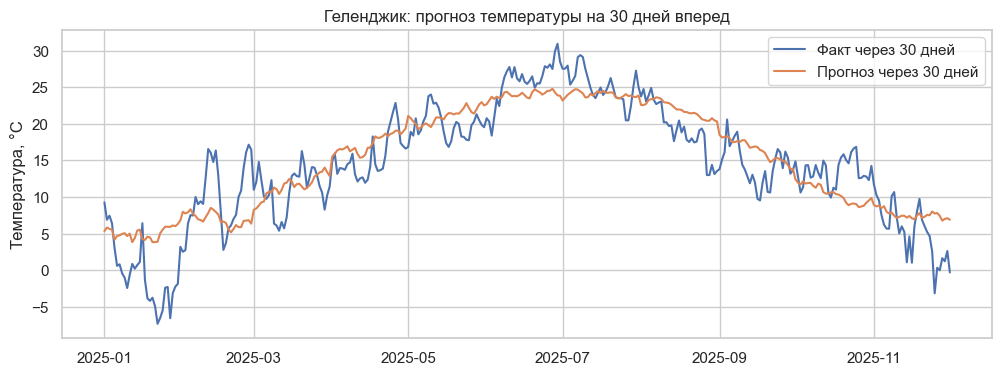

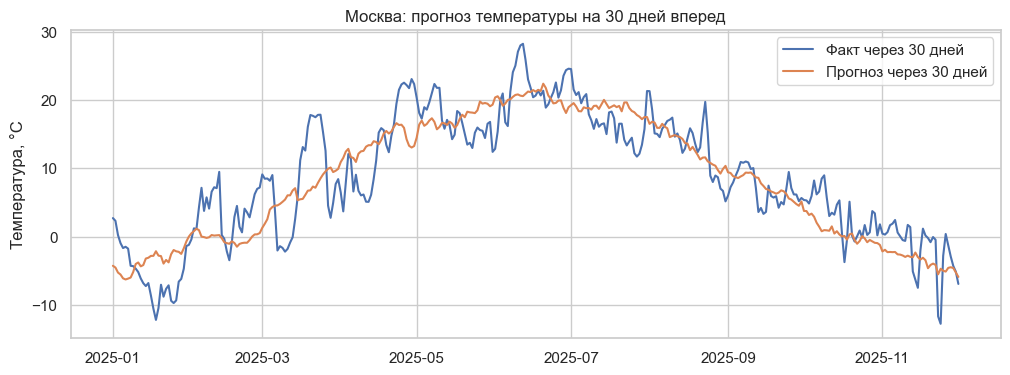

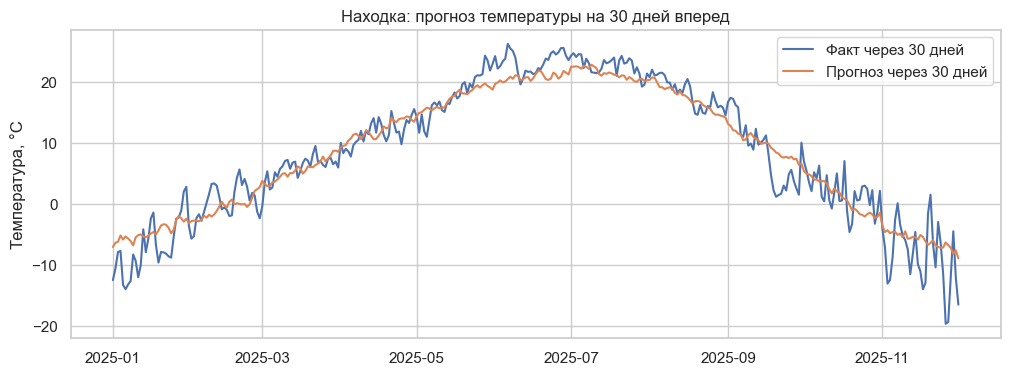

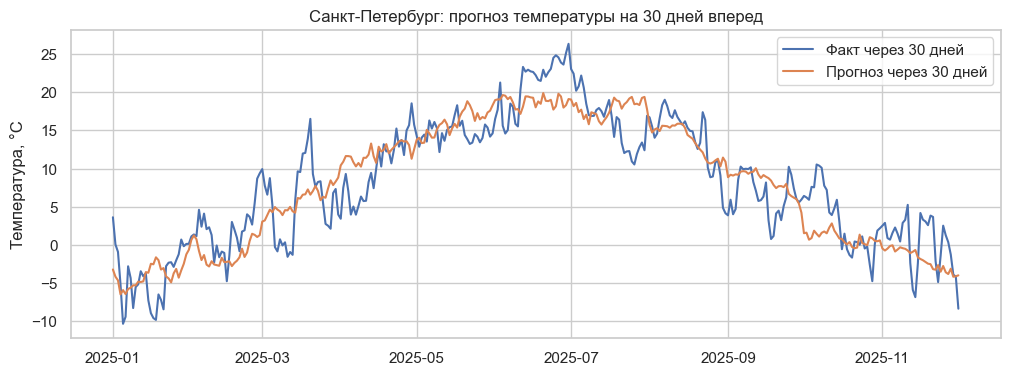

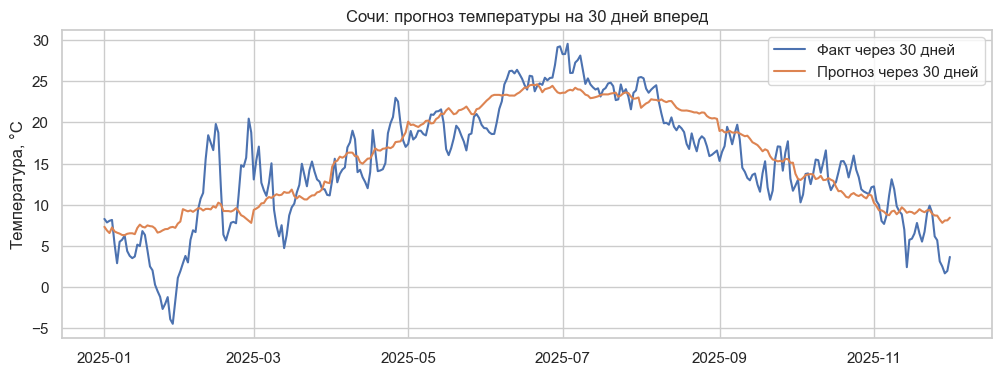

In [183]:

for city in forecast_pred_df["city"].unique():
    part = forecast_pred_df[forecast_pred_df["city"] == city].sort_values("datetime")
    plt.figure(figsize=(12, 4))
    plt.plot(part["datetime"], part["y_true_h30"], label="Факт через 30 дней")
    plt.plot(part["datetime"], part["y_pred_h30"], label="Прогноз через 30 дней")
    plt.title(f"{city}: прогноз температуры на 30 дней вперед")
    plt.ylabel("Температура, °C")
    plt.legend()
    plt.show()

# Анализ остатков.

,city,Shapiro_p,Ljung_Box_p,White_p
0,Благовещенск,6.661589e-01,2.540659e-61,2.909625e-07
1,Геленджик,5.623911e-01,7.752299e-195,1.196892e-14
2,Москва,1.068381e-01,1.577422e-119,1.100228e-02
3,Находка,1.634553e-07,3.496015e-57,2.066029e-13
4,Санкт-Петербург,1.304067e-02,8.984054e-124,7.550551e-01
5,Сочи,7.009664e-03,4.014782e-157,5.832510e-11


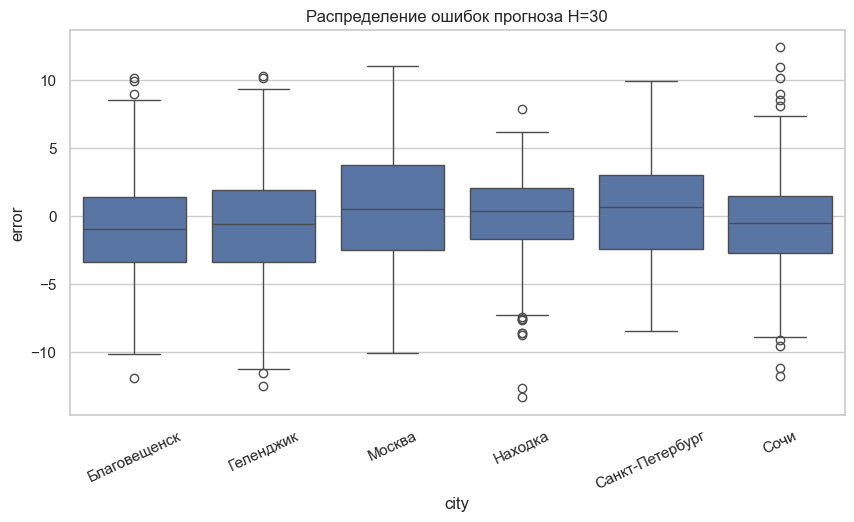

In [184]:
residual_rows = []
for city, part in forecast_pred_df.groupby("city"):
    residuals = part["y_true_h30"] - part["y_pred_h30"]
    shapiro_p = shapiro(residuals.sample(min(len(residuals), 500), random_state=RANDOM_STATE))[1]
    lb_p = acorr_ljungbox(residuals, lags=[10], return_df=True)["lb_pvalue"].iloc[0]

    # Тест Уайта: residual^2 ~ fitted values.
    exog = sm.add_constant(part["y_pred_h30"].values)
    white_p = het_white(residuals.values, exog)[1]

    residual_rows.append({"city": city, "Shapiro_p": shapiro_p, "Ljung_Box_p": lb_p, "White_p": white_p})

residual_table = pd.DataFrame(residual_rows)
display(residual_table)

plt.figure(figsize=(10, 5))
sns.boxplot(data=forecast_pred_df.assign(error=forecast_pred_df["y_true_h30"] - forecast_pred_df["y_pred_h30"]), x="city", y="error")
plt.xticks(rotation=25)
plt.title("Распределение ошибок прогноза H=30")
plt.show()

,city,date,forecast_temp
0,Благовещенск,2026-01-01,-22.398223
1,Благовещенск,2026-01-02,-22.474203
2,Благовещенск,2026-01-03,-22.654467
3,Благовещенск,2026-01-04,-23.039200
4,Благовещенск,2026-01-05,-23.685590
5,Благовещенск,2026-01-06,-24.248265
6,Благовещенск,2026-01-07,-24.383724
7,Благовещенск,2026-01-08,-24.340576
8,Благовещенск,2026-01-09,-24.374562
9,Благовещенск,2026-01-10,-24.258709


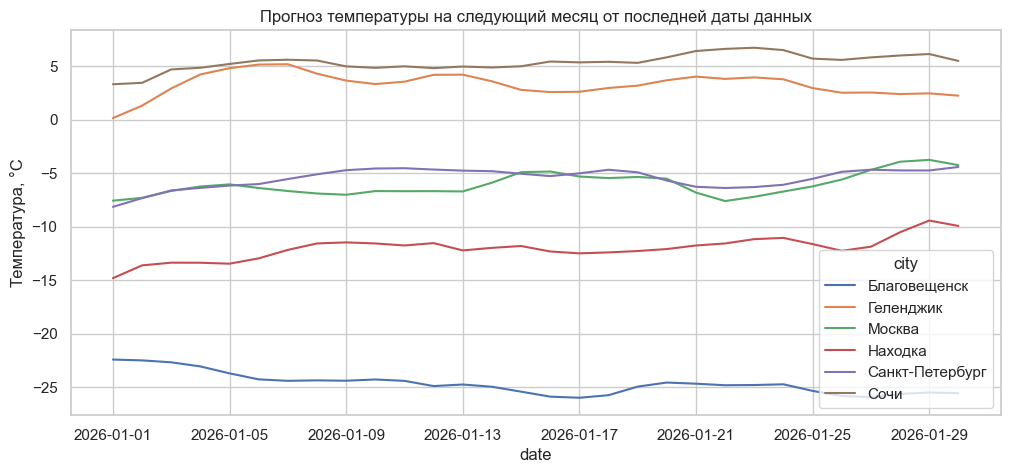

In [185]:
# Пример прогноза на следующий месяц для каждого города: последняя доступная точка.
future_forecasts = []
for city, group in daily.groupby("city"):
    g = group.sort_values("datetime").dropna(subset=forecast_features)
    last_row = g.iloc[[-1]]
    pred_30 = city_models[city].predict(last_row[forecast_features])[0]
    dates = pd.date_range(last_row["datetime"].iloc[0] + pd.Timedelta(days=1), periods=30, freq="D")
    future_forecasts.append(pd.DataFrame({"city": city, "date": dates, "forecast_temp": pred_30}))

future_forecasts = pd.concat(future_forecasts, ignore_index=True)
display(future_forecasts.head(12))

plt.figure(figsize=(12, 5))
sns.lineplot(data=future_forecasts, x="date", y="forecast_temp", hue="city")
plt.title("Прогноз температуры на следующий месяц от последней даты данных")
plt.ylabel("Температура, °C")
plt.show()

### Вывод по прогнозированию

Прогноз на месяц вперед существенно сложнее классификации из-за накопления неопределенности. Ошибка обычно растет с горизонтом. Наиболее устойчивые результаты ожидаются в городах с мягким морским климатом, а наибольшие ошибки — в регионах с резкими температурными перепадами.

## 2.7. Интеграция двух этапов в единый пайплайн

In [186]:
class ClimateForecastPipeline:
    """Двухэтапный pipeline: классификация климата → определение города → выбор city-specific модели прогноза."""

    def __init__(self, climate_classifier, city_classifier, city_models, climate_map):
        self.climate_classifier = climate_classifier
        self.city_classifier = city_classifier
        self.city_models = city_models
        self.climate_map = climate_map

    def predict_climate(self, window_features: pd.DataFrame):
        return self.climate_classifier.predict(window_features)[0]

    def predict_city(self, window_features: pd.DataFrame):
        return self.city_classifier.predict(window_features)[0]

    def forecast_by_city(self, city: str, forecast_features_df: pd.DataFrame):
        return self.city_models[city].predict(forecast_features_df)[0]

    def predict(self, window_features: pd.DataFrame, forecast_features_df: pd.DataFrame):
        predicted_climate = self.predict_climate(window_features)
        predicted_city = self.predict_city(window_features)
        city_climate = self.climate_map[predicted_city]

        consistency_ok = predicted_climate == city_climate
        forecast = self.forecast_by_city(predicted_city, forecast_features_df)

        return {
            "predicted_climate": predicted_climate,
            "predicted_city": predicted_city,
            "city_climate": city_climate,
            "climate_city_consistency": consistency_ok,
            "temperature_forecast_30d": forecast
        }

pipeline = ClimateForecastPipeline(classifier, city_classifier, city_models, climate_map)


sample_window = X.loc[test_mask].iloc[[0]]
actual_city = win.loc[test_mask, "city"].iloc[0]


predicted_city_for_demo = pipeline.predict_city(sample_window)
sample_forecast_row = daily[(daily["city"] == predicted_city_for_demo)].dropna(subset=forecast_features).iloc[[-1]]
result = pipeline.predict(sample_window, sample_forecast_row[forecast_features])

print("Фактический город:", actual_city)
print("Предсказанный климат:", result["predicted_climate"])
print("Предсказанный город для выбора модели:", result["predicted_city"])
print("Согласованность климат/город:", result["climate_city_consistency"])
print("Первые 5 значений прогноза:", result["temperature_forecast_30d"][:5])

Фактический город: Благовещенск
Предсказанный климат: Дальневосточный
Предсказанный город для выбора модели: Благовещенск
Согласованность климат/город: True
Первые 5 значений прогноза: [-22.39822299 -22.47420334 -22.65446716 -23.0392004  -23.6855903 ]


## 2.8. Документирование, сводная таблица и итоговые выводы

In [187]:
summary_table = forecast_metrics.groupby("city")[["MAE", "RMSE", "MAPE_safe", "WAPE", "direction_accuracy"]].mean().reset_index()
summary_table = summary_table.merge(alpha_table, on="city", how="left")
for k, v in classification_metrics.items():
    summary_table[f"classification_{k}"] = v

summary_table["note"] = "MAPE_safe рассчитан только для |T| >= 1°C; WAPE является основной относительной метрикой."
display(summary_table)

,city,MAE,RMSE,MAPE_safe,WAPE,direction_accuracy,best_alpha,val_MAE,classification_accuracy,classification_precision_macro,classification_recall_macro,classification_f1_macro,classification_f1_weighted,classification_roc_auc_ovr,note
0,Благовещенск,2.817337,3.613177,35.423712,20.259044,0.517665,100.0,2.668907,0.782051,0.854753,0.782051,0.766032,0.766032,0.95294,MAPE_safe рассчитан только для |T| >= 1°C; WAP...
1,Геленджик,2.983178,3.799663,37.781512,19.941189,0.508383,100.0,2.834884,0.782051,0.854753,0.782051,0.766032,0.766032,0.95294,MAPE_safe рассчитан только для |T| >= 1°C; WAP...
2,Москва,3.352657,4.087523,56.744054,32.534019,0.505988,10.0,3.358029,0.782051,0.854753,0.782051,0.766032,0.766032,0.95294,MAPE_safe рассчитан только для |T| >= 1°C; WAP...
3,Находка,2.253137,2.893735,45.170253,19.228160,0.511876,10.0,2.249124,0.782051,0.854753,0.782051,0.766032,0.766032,0.95294,MAPE_safe рассчитан только для |T| >= 1°C; WAP...
4,Санкт-Петербург,3.050392,3.749575,58.631050,32.616378,0.505689,100.0,3.197190,0.782051,0.854753,0.782051,0.766032,0.766032,0.95294,MAPE_safe рассчитан только для |T| >= 1°C; WAP...
5,Сочи,2.527205,3.331276,31.854086,16.577911,0.499401,100.0,2.170752,0.782051,0.854753,0.782051,0.766032,0.766032,0.95294,MAPE_safe рассчитан только для |T| >= 1°C; WAP...


## Итоговая интерпретация

1. Двухэтапный подход применим для метеоданных, так как разные города имеют разные климатические режимы и распределения признаков.
2. Классификация климатического типа позволяет выбрать более релевантную forecasting-модель. Для корректного выбора городской модели в pipeline добавлен дополнительный city-router.
3. Validation-период 2024 используется для выбора гиперпараметра Ridge, а 2025 остается независимым тестом.
4. MAPE для температуры нельзя считать основной метрикой, потому что температура может быть около нуля или отрицательной. Поэтому в выводах приоритет имеют MAE, RMSE и WAPE.
5. Удалять выбросы без экспертной проверки нельзя, потому что экстремумы могут быть опасными погодными явлениями.
